In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [33]:
df = pd.read_csv(r"C:\college_recommendation_system\RawData\tgeapcet_2017-2024_dataset.csv")

In [34]:
df.shape

(119307, 13)

In [35]:
df.columns

Index(['inst_code', 'institute_name', 'branch_code', 'branch_name',
       'co_education', 'college_type', 'year_of_estab', 'place', 'dist_code',
       'year', 'cutoff', 'category', 'gender'],
      dtype='object')

In [36]:
df.head(10)

,inst_code,institute_name,branch_code,branch_name,co_education,college_type,year_of_estab,place,dist_code,year,cutoff,category,gender
0,AARM,AAR MAHAVEER ENGINEERING COLLEGE,CSE,computer science and engineering,COED,PVT,2010.0,BANDLAGUDA,HYD,2017,26907.0,OC,Boys
1,AARM,AAR MAHAVEER ENGINEERING COLLEGE,ECE,electronics and communication engineering,COED,PVT,2010.0,BANDLAGUDA,HYD,2017,33871.0,OC,Boys
2,AARM,AAR MAHAVEER ENGINEERING COLLEGE,EEE,electrical and electronics engineering,COED,PVT,2010.0,BANDLAGUDA,HYD,2017,39938.0,OC,Boys
3,AARM,AAR MAHAVEER ENGINEERING COLLEGE,MEC,mechanical engineering,COED,PVT,2010.0,BANDLAGUDA,HYD,2017,38774.0,OC,Boys
4,ACEG,A C E ENGINEERING COLLEGE,CIV,civil engineering,COED,PVT,2007.0,GHATKESAR,MDL,2017,33769.0,OC,Boys
5,ACEG,A C E ENGINEERING COLLEGE,CSE,computer science and engineering,COED,PVT,2007.0,GHATKESAR,MDL,2017,22063.0,OC,Boys
6,ACEG,A C E ENGINEERING COLLEGE,ECE,electronics and communication engineering,COED,PVT,2007.0,GHATKESAR,MDL,2017,27256.0,OC,Boys
7,ACEG,A C E ENGINEERING COLLEGE,EEE,electrical and electronics engineering,COED,PVT,2007.0,GHATKESAR,MDL,2017,35868.0,OC,Boys
8,ACEG,A C E ENGINEERING COLLEGE,MEC,mechanical engineering,COED,PVT,2007.0,GHATKESAR,MDL,2017,41309.0,OC,Boys
9,AHTC,ABHINAV HI-TECH COLLEGE OF ENGINEERING,CIV,civil engineering,COED,PVT,2002.0,MOINABAD,RR,2017,96450.0,OC,Boys


In [37]:
df.branch_code.unique()

array(['CSE', 'ECE', 'EEE', 'MEC', 'CIV', 'INF', 'CHE', 'AGR', 'BIO',
       'IPE', 'DRG', 'FDS', 'EIE', 'ANE', 'ECM', 'DTD', 'FSP', 'PLG',
       'MET', 'MIN', 'CEE', 'MNT', 'MCT', 'MMT', 'AUT', 'BME', 'FPT',
       'TEX', 'PHM', 'PHE', 'PHD', 'CSI', 'AI', 'MMS', 'MTE', 'CSN',
       'ECI', 'ITE', 'CSB', 'CSM', 'CSD', 'CSO', 'CSC', 'CSW', 'AID',
       'CIC', 'FDT', 'CSG', 'AIM', 'ARB', 'CME', 'CSA', 'BSE', 'GEO',
       'CS', 'EVL', 'ETM', 'CST'], dtype=object)

In [38]:
df.branch_name.unique()

array(['computer science and engineering',
       'electronics and communication engineering',
       'electrical and electronics engineering', 'mechanical engineering',
       'civil engineering', 'information technology',
       'chemical engineering', 'agricultural engineering',
       'bio-technology', 'industrial production engineering', 'dairying',
       'food science', 'electronics and instrumentation engineering',
       'aeronautical engineering', 'electronics and computer engineering',
       'digital techniques for design and planning',
       'facilities and services planning', 'planning',
       'metallurgical engineering', 'mining engineering',
       'civil environmental engineering',
       'material science and nano technology',
       'mechanical (mechtronics) engineering',
       'metallurgy and material engineering', 'automobile engineering',
       'bio-medical engineering', 'food processing technology',
       'textile technology', 'b. pharmacy (m.p.c. stream)',


In [39]:
df.co_education.unique()

array(['COED', 'GIRLS'], dtype=object)

In [40]:
df.college_type.unique()

array(['PVT', 'UNIV', 'SF', 'GOV', nan], dtype=object)

In [41]:
df.category.unique()

array(['OC', 'BC_A', 'BC_B', 'BC_C', 'BC_D', 'BC_E', 'SC', 'ST', 'EWS'],
      dtype=object)

In [42]:
df.gender.unique()

array(['Boys', 'Girls'], dtype=object)

In [43]:
df.isnull().sum()

inst_code             0
institute_name        0
branch_code           0
branch_name           0
co_education          0
college_type      17208
year_of_estab     12802
place                16
dist_code             0
year                  0
cutoff                0
category              0
gender                0
dtype: int64

In [44]:

df["category_gender"] = (
    df["category"].astype(str) + "_" + df["gender"].astype(str)
)

df['year_of_estab'] = df['year_of_estab'].fillna(df['year_of_estab'].median())

df['place'] = df['place'].fillna("Unknown")

df['college_type'] = df['college_type'].fillna(df['college_type'].mode()[0])

df.isnull().sum()


inst_code          0
institute_name     0
branch_code        0
branch_name        0
co_education       0
college_type       0
year_of_estab      0
place              0
dist_code          0
year               0
cutoff             0
category           0
gender             0
category_gender    0
dtype: int64

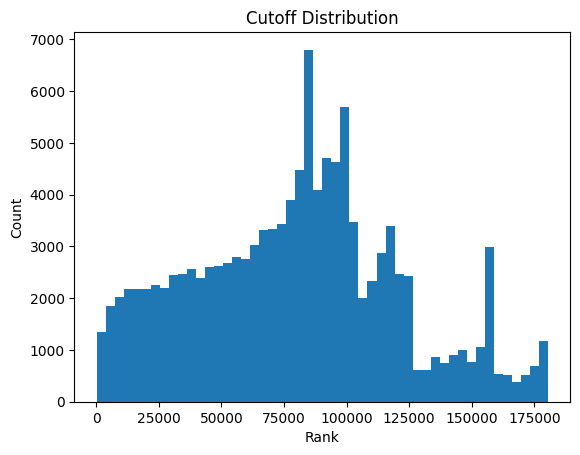

In [45]:
import matplotlib.pyplot as plt

plt.hist(df['cutoff'], bins=50)
plt.title("Cutoff Distribution")
plt.xlabel("Rank")
plt.ylabel("Count")
plt.show()

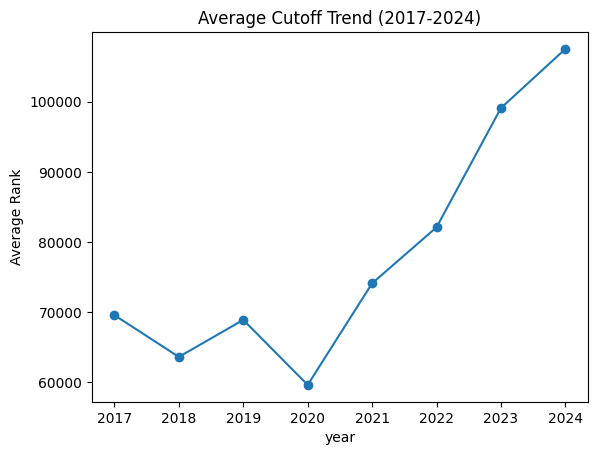

In [46]:
year_trend = df.groupby('year')['cutoff'].mean()

year_trend.plot(marker='o')
plt.title("Average Cutoff Trend (2017-2024)")
plt.ylabel("Average Rank")
plt.show()

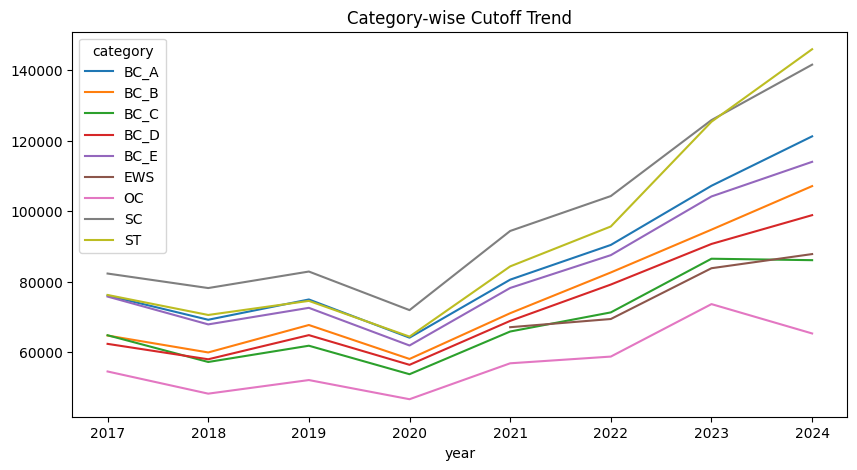

In [47]:
category_trend = df.groupby(['year','category'])['cutoff'].mean().unstack()

category_trend.plot(figsize=(10,5))
plt.title("Category-wise Cutoff Trend")
plt.show()

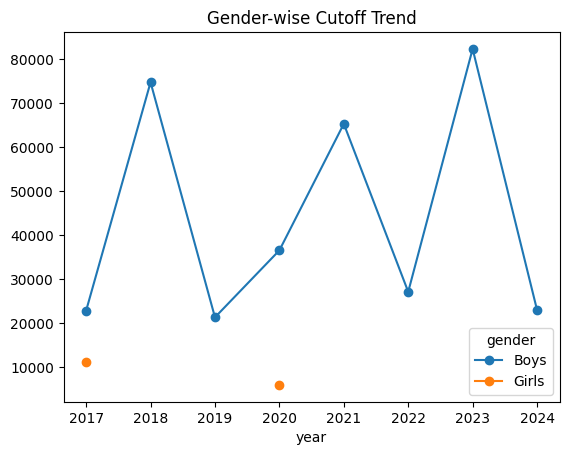

In [60]:
gender_trend = df.groupby(['year','gender'])['cutoff'].mean().unstack()

gender_trend.plot(marker='o')
plt.title("Gender-wise Cutoff Trend")
plt.show()

In [ ]:
branch_demand = df.groupby('branch_name')['cutoff'].mean().sort_values(ascending = True)
ax=branch_demand.head(10).plot(kind='barh',figsize=(10,6))
for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y()+bar.get_height()/2
    ax.text(width+500,y,f'{int(width)}',va = 'center')
plt.title("Most Competitive Branches ")
plt.xlabel("Cuttoff")
plt.ylabel("Branch Name")
plt.show()

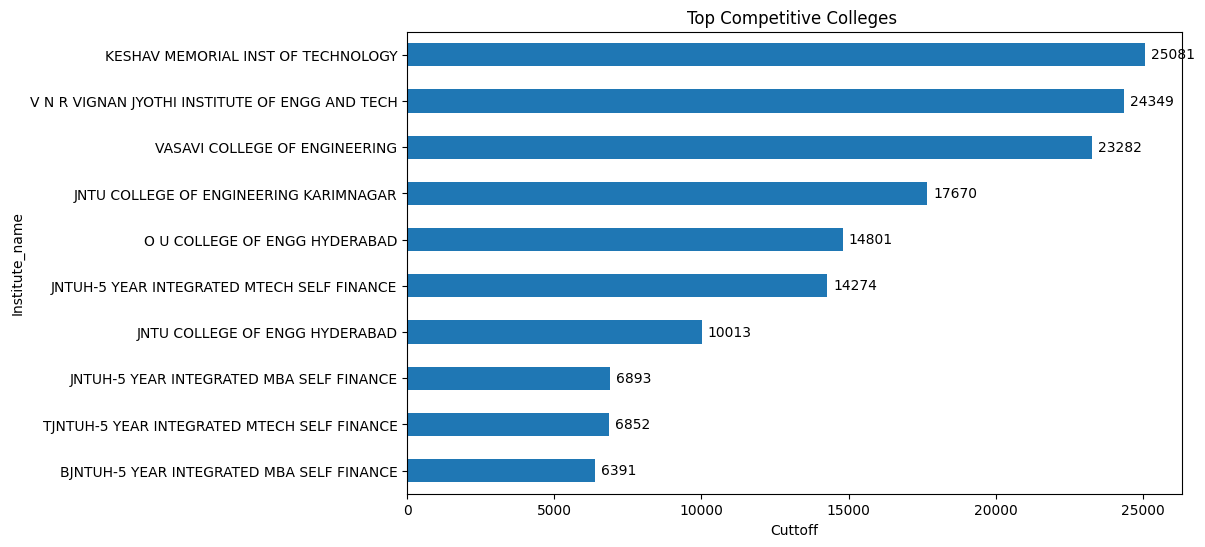

In [28]:
college_comp = df.groupby('institute_name')['cutoff'].mean().sort_values()

ax=college_comp.head(10).plot(kind='barh',figsize=(10,6))
for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y()+bar.get_height()/2
    ax.text(width+200,y,f'{int(width)}',va = 'center')
plt.title("Top Competitive Colleges ")
plt.xlabel("Cuttoff")
plt.ylabel("Institute_name")
plt.show()

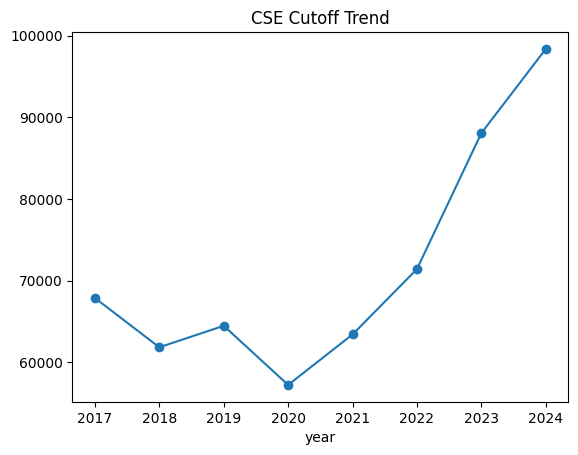

In [146]:
cse = df[df['branch_name'].str.contains("computer", case=False)]

cse_trend = cse.groupby('year')['cutoff'].mean()

cse_trend.plot(marker='o')
plt.title("CSE Cutoff Trend")
plt.show()

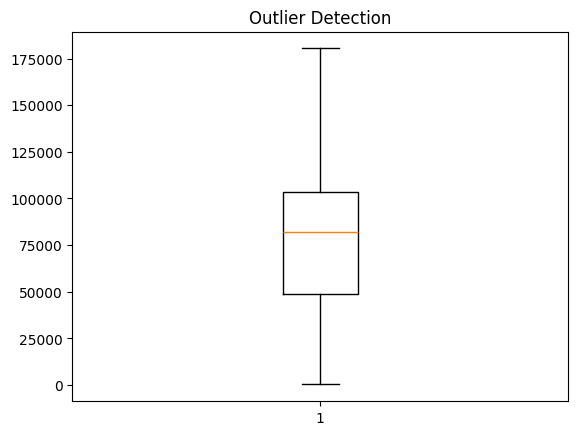

In [147]:
plt.boxplot(df['cutoff'])
plt.title("Outlier Detection")
plt.show()

In [148]:
from sklearn.preprocessing import LabelEncoder

le_college = LabelEncoder()/
df["inst_code"] = le_college.fit_transform(df["inst_code"])

In [149]:
le_branch = LabelEncoder()
df["branch_code"] = le_branch.fit_transform(df["branch_code"])

In [150]:
df["category"] = df["category"].fillna("EWS")

category_map = {
    "OC":0,
    "BC_A":1,
    "BC_B":2,
    "BC_C":3,
    "BC_D":4,
    "BC_E":5,
    "SC":6,
    "ST":7,
    "EWS":8
}

df["category"] = df["category"].map(category_map)

In [151]:
gender_map = {
    "COED":0,
    "GIRLS":1
}
df["co_education"] = df["co_education"].map(gender_map)

In [152]:
le_location = LabelEncoder()
df["dist_code"] = le_location.fit_transform(df["dist_code"])

In [153]:
gender_map = {
    "Boys": 0,
    "Girls": 1
}

df["gender"] = df["gender"].map(gender_map)

In [154]:
df = df.drop(columns=[
    "institute_name",
    "branch_name",
    "category",
    "gender",
    "place"
])

In [155]:
df["category_gender"] = df["category_gender"].str.strip().str.upper()

In [156]:
le_catgen = LabelEncoder()
df["catgen_id"] = le_catgen.fit_transform(df["category_gender"])

In [157]:
df = df.drop(columns=["category_gender","college_type","year_of_estab"])

In [158]:
df.head()

,inst_code,branch_code,co_education,dist_code,year,cutoff,catgen_id
0,0,20,0,2,2017,26907.0,12
1,0,30,0,2,2017,33871.0,12
2,0,33,0,2,2017,39938.0,12
3,0,46,0,2,2017,38774.0,12
4,1,13,0,11,2017,33769.0,12


Linear Regression

In [165]:
import warnings
warnings.filterwarnings("ignore")
# STEP 1 — Sort data
df = df.sort_values(by=['inst_code','branch_code','catgen_id','year'])

# STEP 2 — Create Previous Year Cutoff
df['prev_cutoff'] = df.groupby([
    'inst_code',
    'branch_code',
    'catgen_id'
])['cutoff'].shift(1)

# STEP 3 — Fill missing values
df['prev_cutoff'] = df['prev_cutoff'].fillna(0)

# STEP 4 — Train/Test Split
train = df[df['year'] < 2024]
test  = df[df['year'] == 2024]

# STEP 5 — Features
features = [
    'inst_code',
    'branch_code',
    'co_education',
    'dist_code',
    'catgen_id',
    'prev_cutoff'
]

X_train = train[features]
y_train = train['cutoff']

X_test = test[features]
y_test = test['cutoff']

# STEP 6 — Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# STEP 7 — Predict 2024
test['predicted_cutoff_2024'] = model.predict(X_test)

# STEP 8 — Store Predictions
pred_2024 = test[[
    'inst_code',
    'branch_code',
    'catgen_id',
    'cutoff',
    'predicted_cutoff_2024'
]]

pred_2024.to_csv("predicted_2024_cutoffs.csv", index=False)

print("✅ 2024 Predictions Saved Successfully")

✅ 2024 Predictions Saved Successfully


In [166]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, test['predicted_cutoff_2024'])
r2  = r2_score(y_test, test['predicted_cutoff_2024'])

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 37290.88182030934
R2 Score: 0.2817301987727524


XG BOOST

In [164]:
# ==============================
# 1️⃣ Import Libraries
# ==============================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor


# ==============================
# 3️⃣ Sort Properly
# ==============================
df = df.sort_values(
    ["inst_code", "branch_code", "catgen_id", "year"]
).reset_index(drop=True)

# ==============================
# 4️⃣ Feature Engineering
# ==============================

# Previous year cutoff
df["prev_cutoff"] = (
    df.groupby(["inst_code", "branch_code", "catgen_id"])["cutoff"]
    .shift(1)
)

# 2-year lag
df["prev_cutoff_2"] = (
    df.groupby(["inst_code", "branch_code", "catgen_id"])["cutoff"]
    .shift(2)
)

# 3-year rolling mean
df["rolling_mean_3"] = (
    df.groupby(["inst_code", "branch_code", "catgen_id"])["cutoff"]
    .transform(lambda x: x.rolling(3).mean())
)

# Cutoff change
df["cutoff_change"] = df["cutoff"] - df["prev_cutoff"]

# Drop NaNs
df = df.dropna().reset_index(drop=True)

# ==============================
# 5️⃣ Define Features
# ==============================
features = [
    "inst_code",
    "branch_code",
    "co_education",
    "dist_code",
    # try removing year later if needed
    "year",
    "catgen_id",
    "prev_cutoff",
    "prev_cutoff_2",
    "rolling_mean_3",
    
]

# ==============================
# 6️⃣ Time-Based Split
# ==============================
train = df[df["year"] < 2024]
test = df[df["year"] == 2024]

X_train = train[features]
y_train = train["cutoff"]

X_test = test[features]
y_test = test["cutoff"]

# ==============================
# 7️⃣ Train XGBoost Model
# ==============================
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ==============================
# 8️⃣ Predict
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 9️⃣ Evaluation
# ==============================
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost MAE:", mae)
print("XGBoost R2 :", r2)

# ==============================
# 🔟 Save Predictions
# ==============================
results = test.copy()
results["predicted_cutoff"] = y_pred
results["error"] = results["cutoff"] - results["predicted_cutoff"]

results.to_csv("C:\\college_recommendation_system\\CleanData\\xgboost_cutoff_predictions_2024.csv", index=False)

print("Predictions saved to xgboost_cutoff_predictions_2024.csv")

XGBoost MAE: 7474.103729958992
XGBoost R2 : 0.9517620452587877
Predictions saved to xgboost_cutoff_predictions_2024.csv
